# **Creating all figures as requested in the Data Analyst Capstone Project PowerPoint presentation**

## *Bar chart ordered from the highest to lowest number of job postings by location - Module 1*

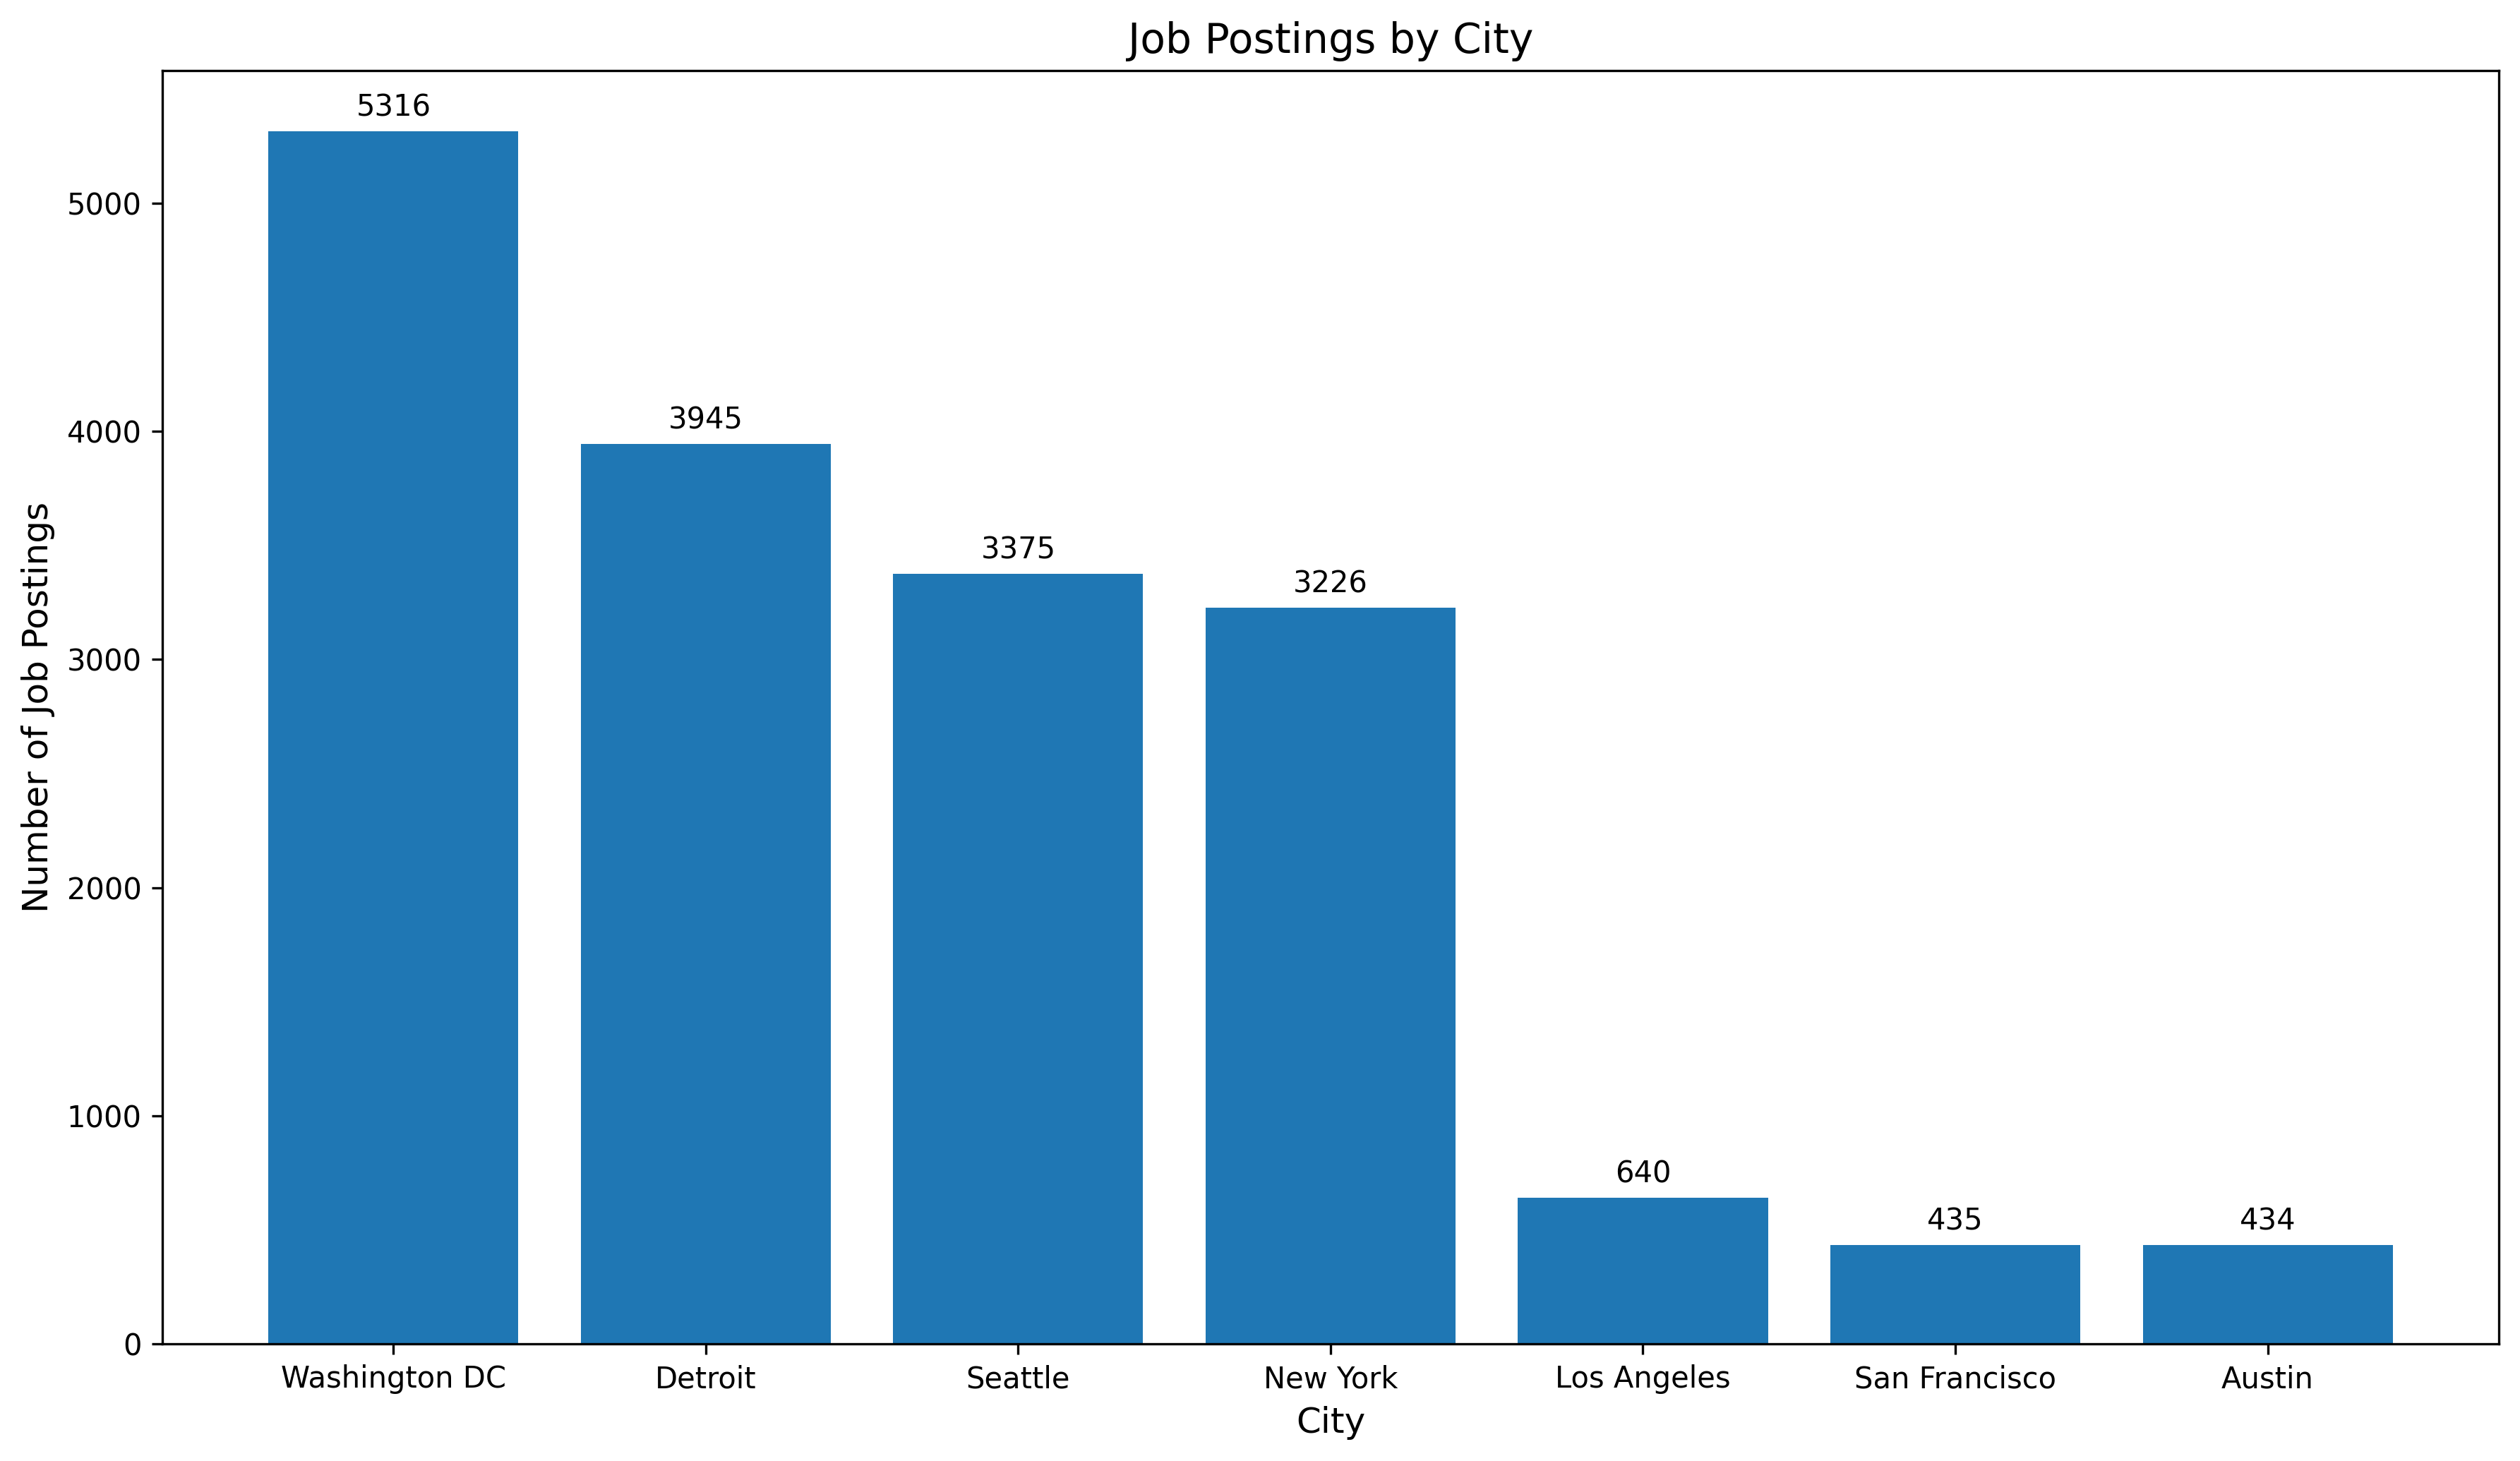

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

data = [
    ['Los Angeles', 640],
    ['New York', 3226],
    ['San Francisco', 435],
    ['Washington DC', 5316],
    ['Seattle', 3375],
    ['Austin', 434],
    ['Detroit', 3945]
]

df_jobs = pd.DataFrame(data, columns=['City', 'Job_Postings']).sort_values(
    'Job_Postings', ascending=False
)

plt.figure(figsize=(12,7), dpi=300)

bars = plt.bar(df_jobs['City'], df_jobs['Job_Postings'])

plt.bar_label(bars, padding=3)  # simple built-in labeling

plt.title('Job Postings by City', fontsize=14)
plt.xlabel('City', fontsize=12)
plt.ylabel('Number of Job Postings', fontsize=12)

plt.xticks(rotation=0)

plt.tight_layout()

plt.savefig("job_postings.png", dpi=300, bbox_inches='tight')
plt.show()

## *Bar chart ordered from the highest to the lowest average salary per programming language - Module 1*

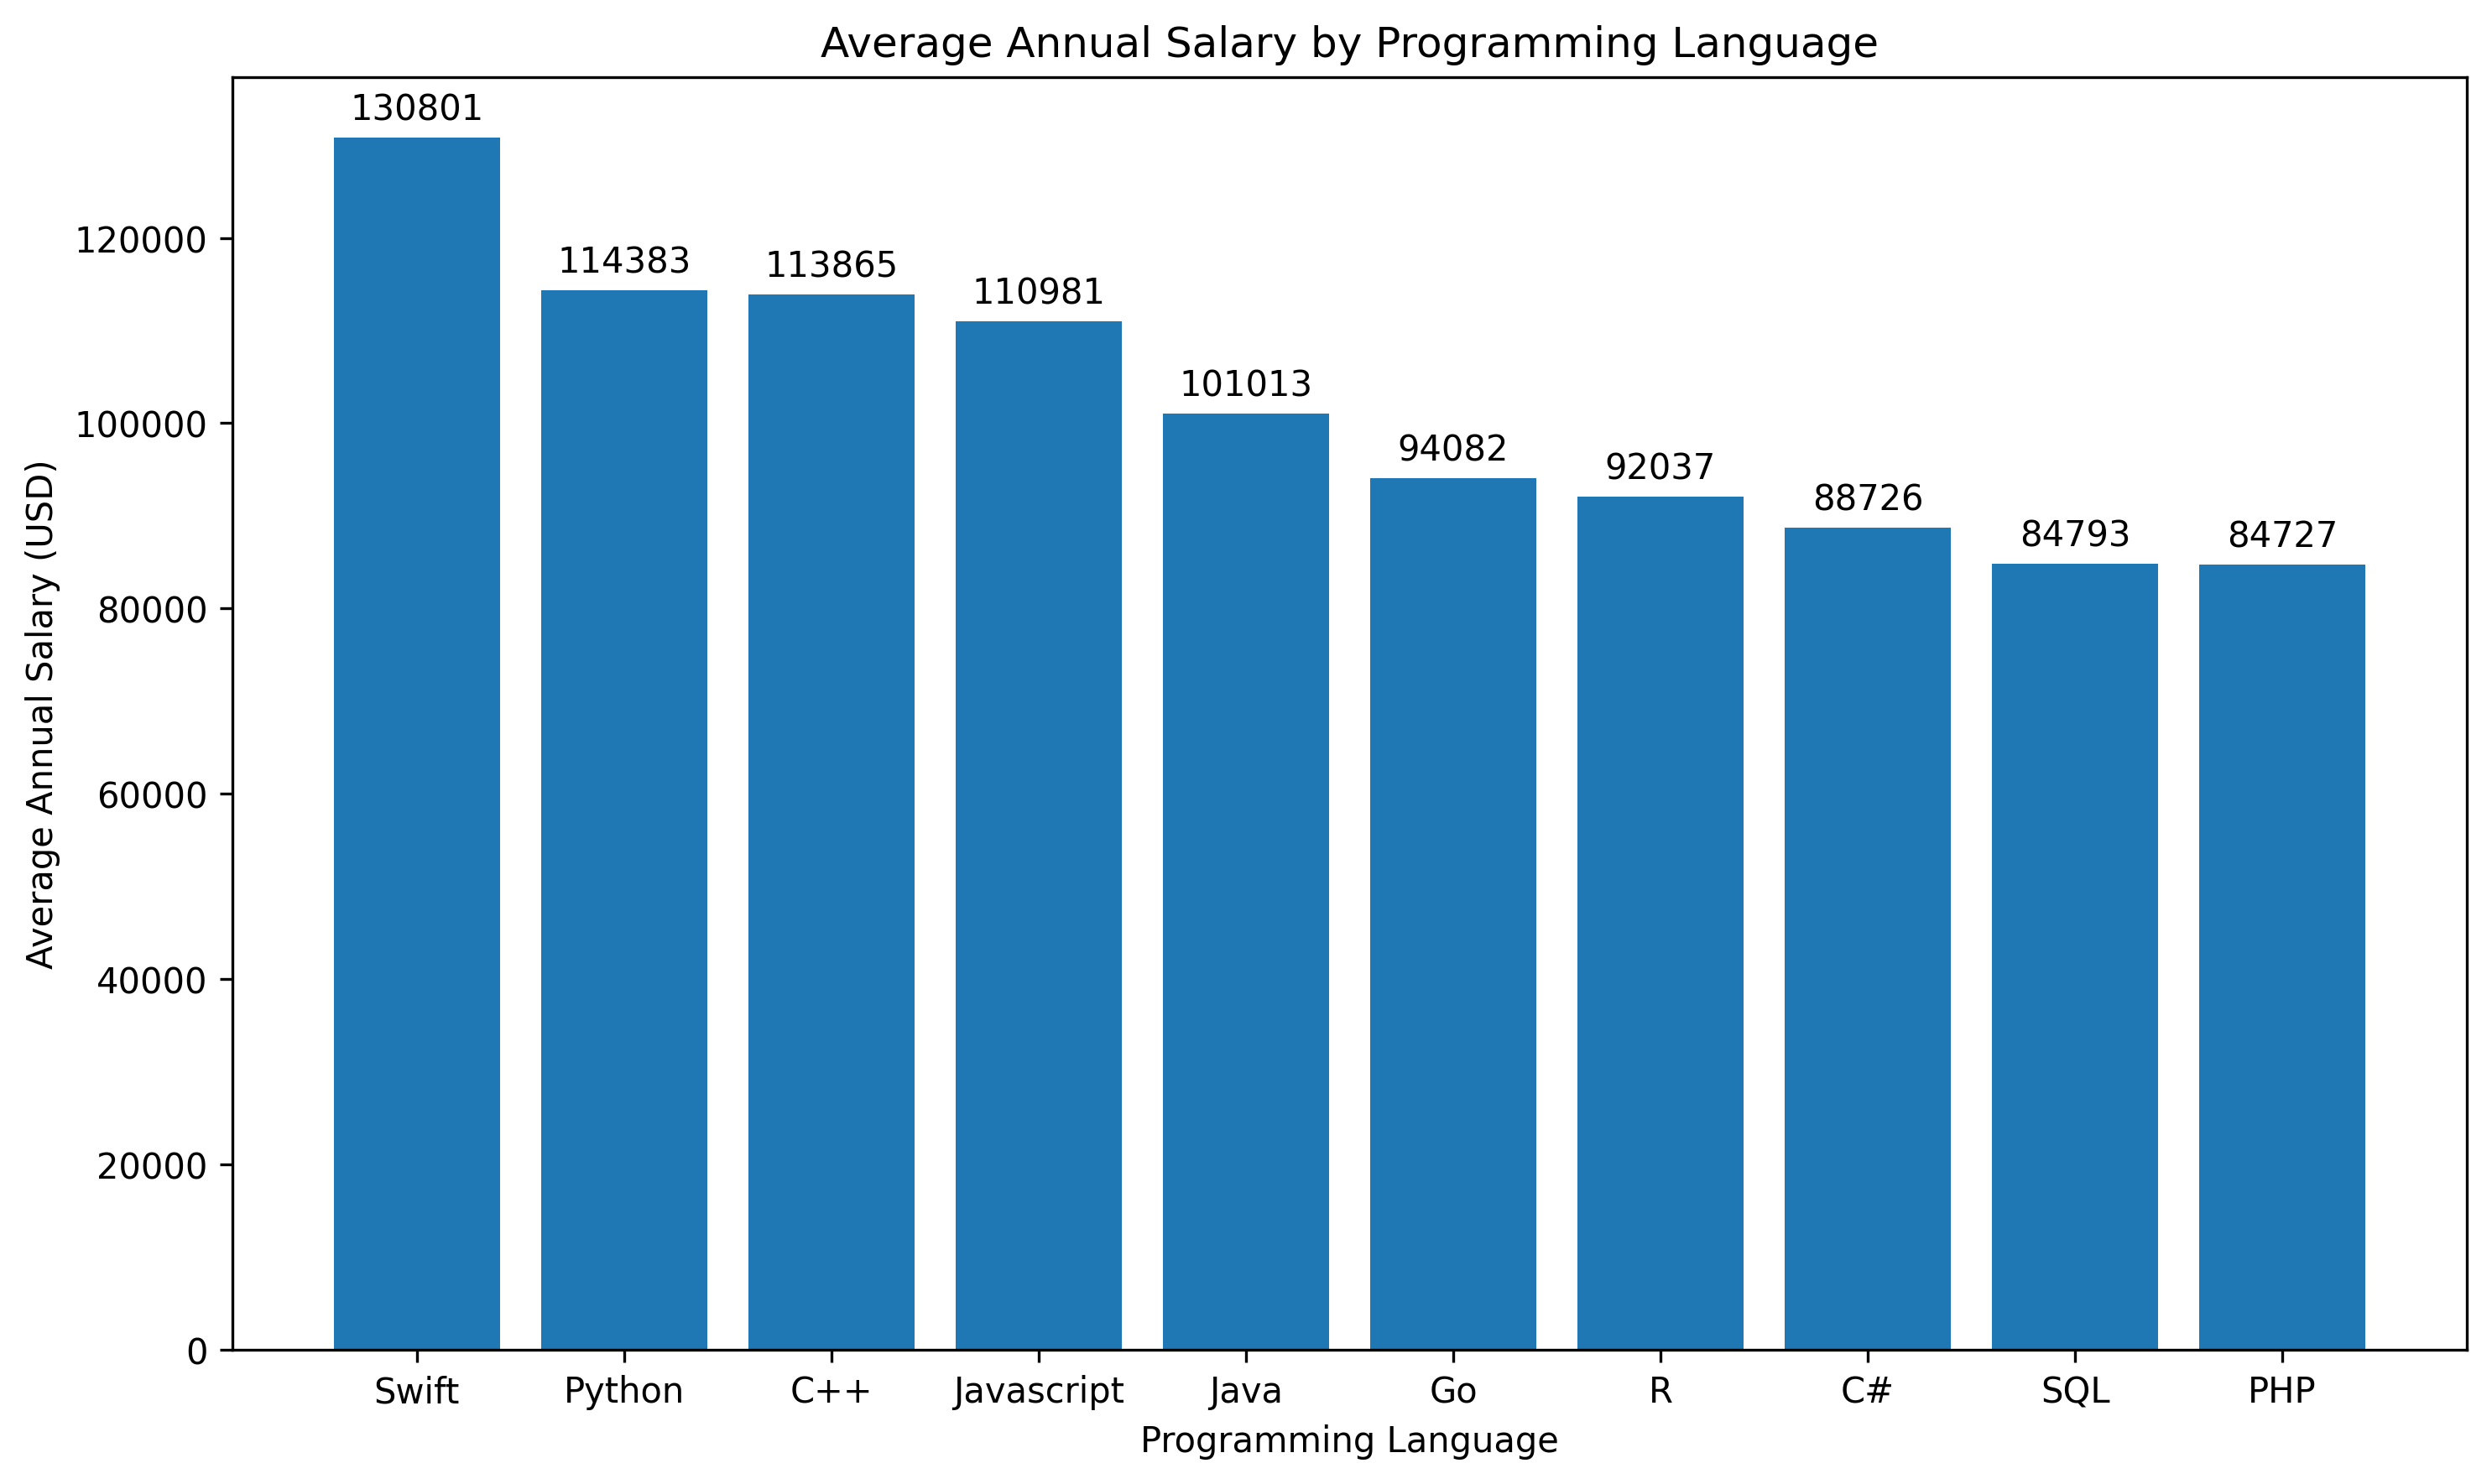

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# Load CSV file
# -------------------------
df_lang = pd.read_csv("popular-languages.csv")

# -------------------------
# Clean salary column ($ → int)
# -------------------------
df_lang['Average_Annual_Salary'] = (
    df_lang['Average_Annual_Salary']
    .replace(r'[\$,]', '', regex=True)
    .astype(int)
)

# -------------------------
# Sort descending
# -------------------------
df_lang = df_lang.sort_values(
    'Average_Annual_Salary',
    ascending=False
)

# -------------------------
# Plot
# -------------------------
plt.figure(figsize=(10,6), dpi=300)

bars = plt.bar(
    df_lang['Language'],
    df_lang['Average_Annual_Salary']
)

plt.bar_label(bars, padding=3)

plt.title('Average Annual Salary by Programming Language')
plt.xlabel('Programming Language')
plt.ylabel('Average Annual Salary (USD)')

plt.xticks(rotation=0)

plt.tight_layout()

# -------------------------
# Save for PPT
# -------------------------
plt.savefig(
    "language_salary.png",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## *Bar charts of programming language and databases current usage and future preferences – Stack Overflow Developer Survey Analysis Module 4*

In [43]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
# Read csv file
df = pd.read_csv('/Users/carolinasanabria/Downloads/survey_data_updated.csv')
print("Dimensions:", df.shape)
print()
df.head()

Dimensions: (18845, 114)



,ResponseId,MainBranch,Age,Employment,RemoteWork,Check,CodingActivities,EdLevel,LearnCode,LearnCodeOnline,...,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,SurveyLength,SurveyEase,ConvertedCompYearly,JobSat
0,2,I am a developer by profession,35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Bachelor's degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,0.0,0.0,0.0,0.0,0.0,0.0,NaN,NaN,NaN,NaN
1,3,I am a developer by profession,45-54 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects;Other...,"Master's degree (M.A., M.S., M.Eng., MBA, etc.)",Books / Physical media;Colleague;On the job tr...,Technical documentation;Blogs;Books;Written Tu...,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Easy,NaN,NaN
2,10,I am a developer by profession,35-44 years old,"Independent contractor, freelancer, or self-em...",Remote,Apples,Bootstrapping a business,"Master's degree (M.A., M.S., M.Eng., MBA, etc.)",On the job training;Other online resources (e....,Technical documentation;Blogs;Written Tutorial...,...,NaN,NaN,NaN,NaN,NaN,NaN,Too long,Easy,NaN,NaN
3,11,"I used to be a developer by profession, but no...",35-44 years old,"Employed, full-time",Remote,Apples,Hobby;Contribute to open-source projects,"Bachelor's degree (B.A., B.S., B.Eng., etc.)",Books / Physical media;Other online resources ...,Technical documentation;Books;Written Tutorial...,...,25.0,10.0,0.0,15.0,0.0,0.0,Appropriate in length,Easy,NaN,8.0
4,12,I am a developer by profession,45-54 years old,"Employed, full-time",In-person,Apples,Hobby;School or academic work,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)","Books / Physical media;School (i.e., Universit...",NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,Appropriate in length,Neither easy nor difficult,NaN,NaN


In [45]:
import pandas as pd

# -------------------------
# Function to explode semicolon-separated columns
# -------------------------
def explode_column(df, column):
    temp = df[[column]].dropna().copy()
    temp[column] = temp[column].astype(str).str.split(';')
    temp = temp.explode(column)
    temp[column] = temp[column].str.strip()
    return temp

# -------------------------
# Languages
# -------------------------
lang_current = explode_column(df, 'LanguageHaveWorkedWith')
lang_future = explode_column(df, 'LanguageWantToWorkWith')

top_lang_current = (
    lang_current['LanguageHaveWorkedWith']
    .value_counts()
    .head(10)
    .reset_index()
)
top_lang_current.columns = ['Language', 'Count']

top_lang_future = (
    lang_future['LanguageWantToWorkWith']
    .value_counts()
    .head(10)
    .reset_index()
)
top_lang_future.columns = ['Language', 'Count']

# -------------------------
# Databases
# -------------------------
db_current = explode_column(df, 'DatabaseHaveWorkedWith')
db_future = explode_column(df, 'DatabaseWantToWorkWith')

top_db_current = (
    db_current['DatabaseHaveWorkedWith']
    .value_counts()
    .head(10)
    .reset_index()
)
top_db_current.columns = ['Database', 'Count']

top_db_future = (
    db_future['DatabaseWantToWorkWith']
    .value_counts()
    .head(10)
    .reset_index()
)
top_db_future.columns = ['Database', 'Count']

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="white")

def plot_bar_sns(df_plot, x, y, title, palette, filename):
    plt.figure(figsize=(8,5), dpi=300)
    
    ax = sns.barplot(
        data=df_plot,
        x=x,
        y=y,
        hue=x,
        palette=palette,
        dodge=False,
        legend=False
    )
    
    #for container in ax.containers:
    #    ax.bar_label(container, padding=3)
    
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    
    # SAVE INSIDE FUNCTION
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

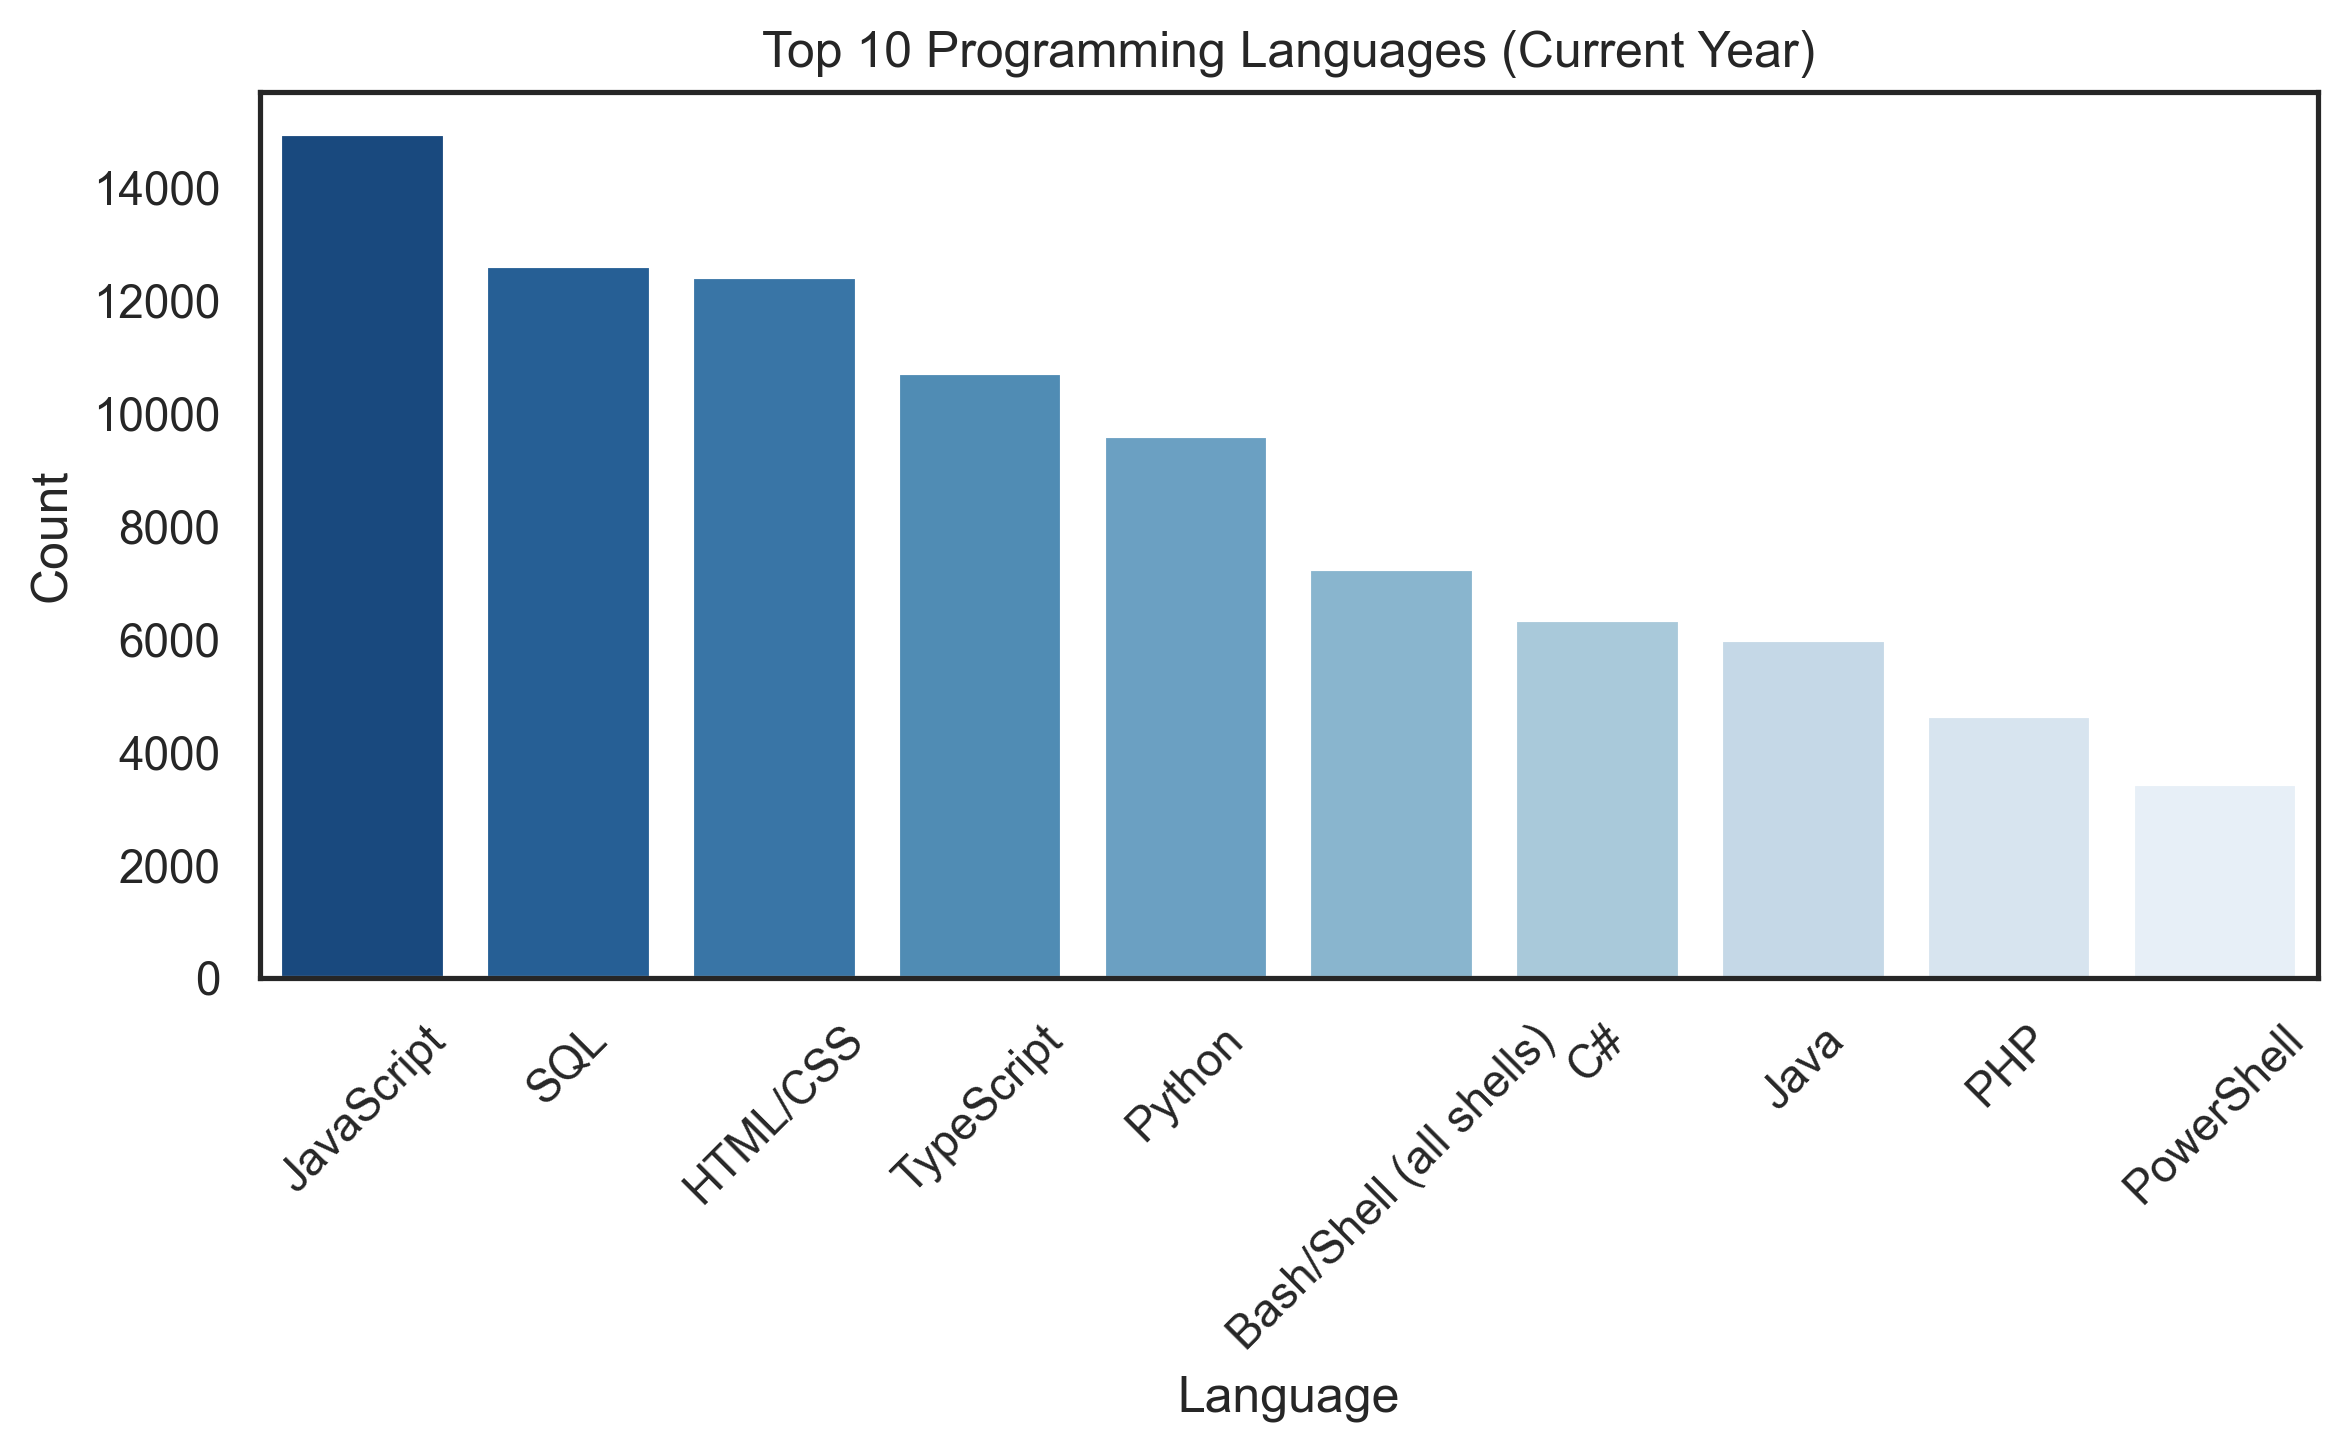

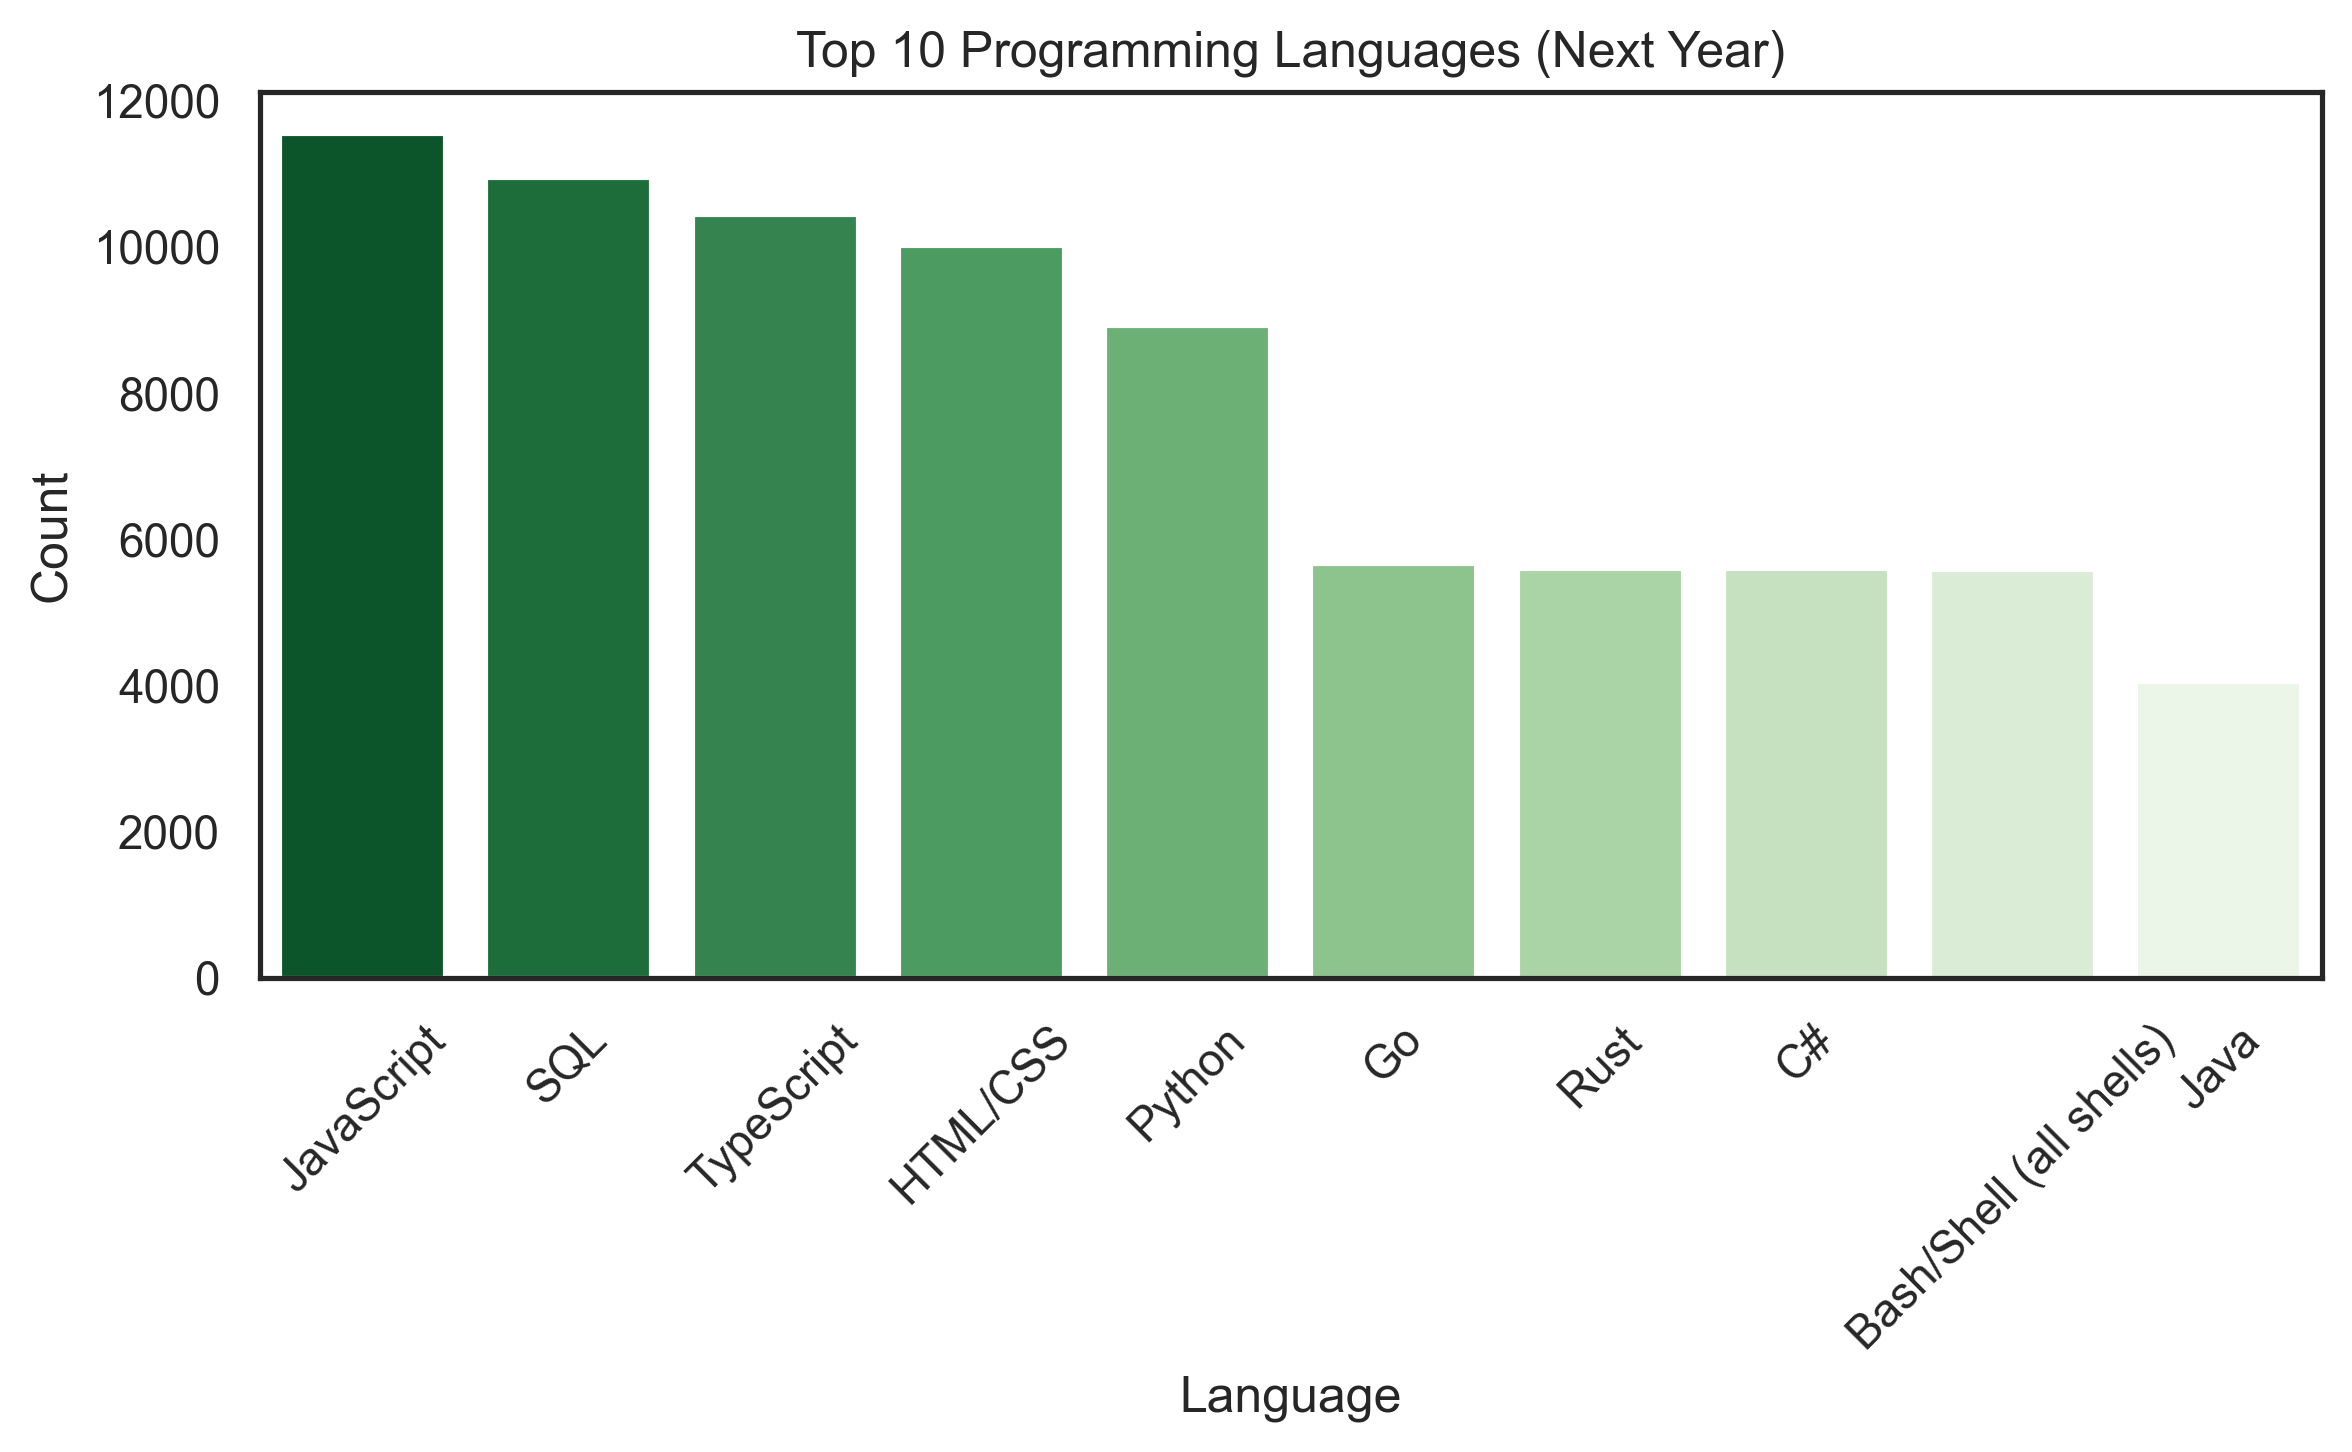

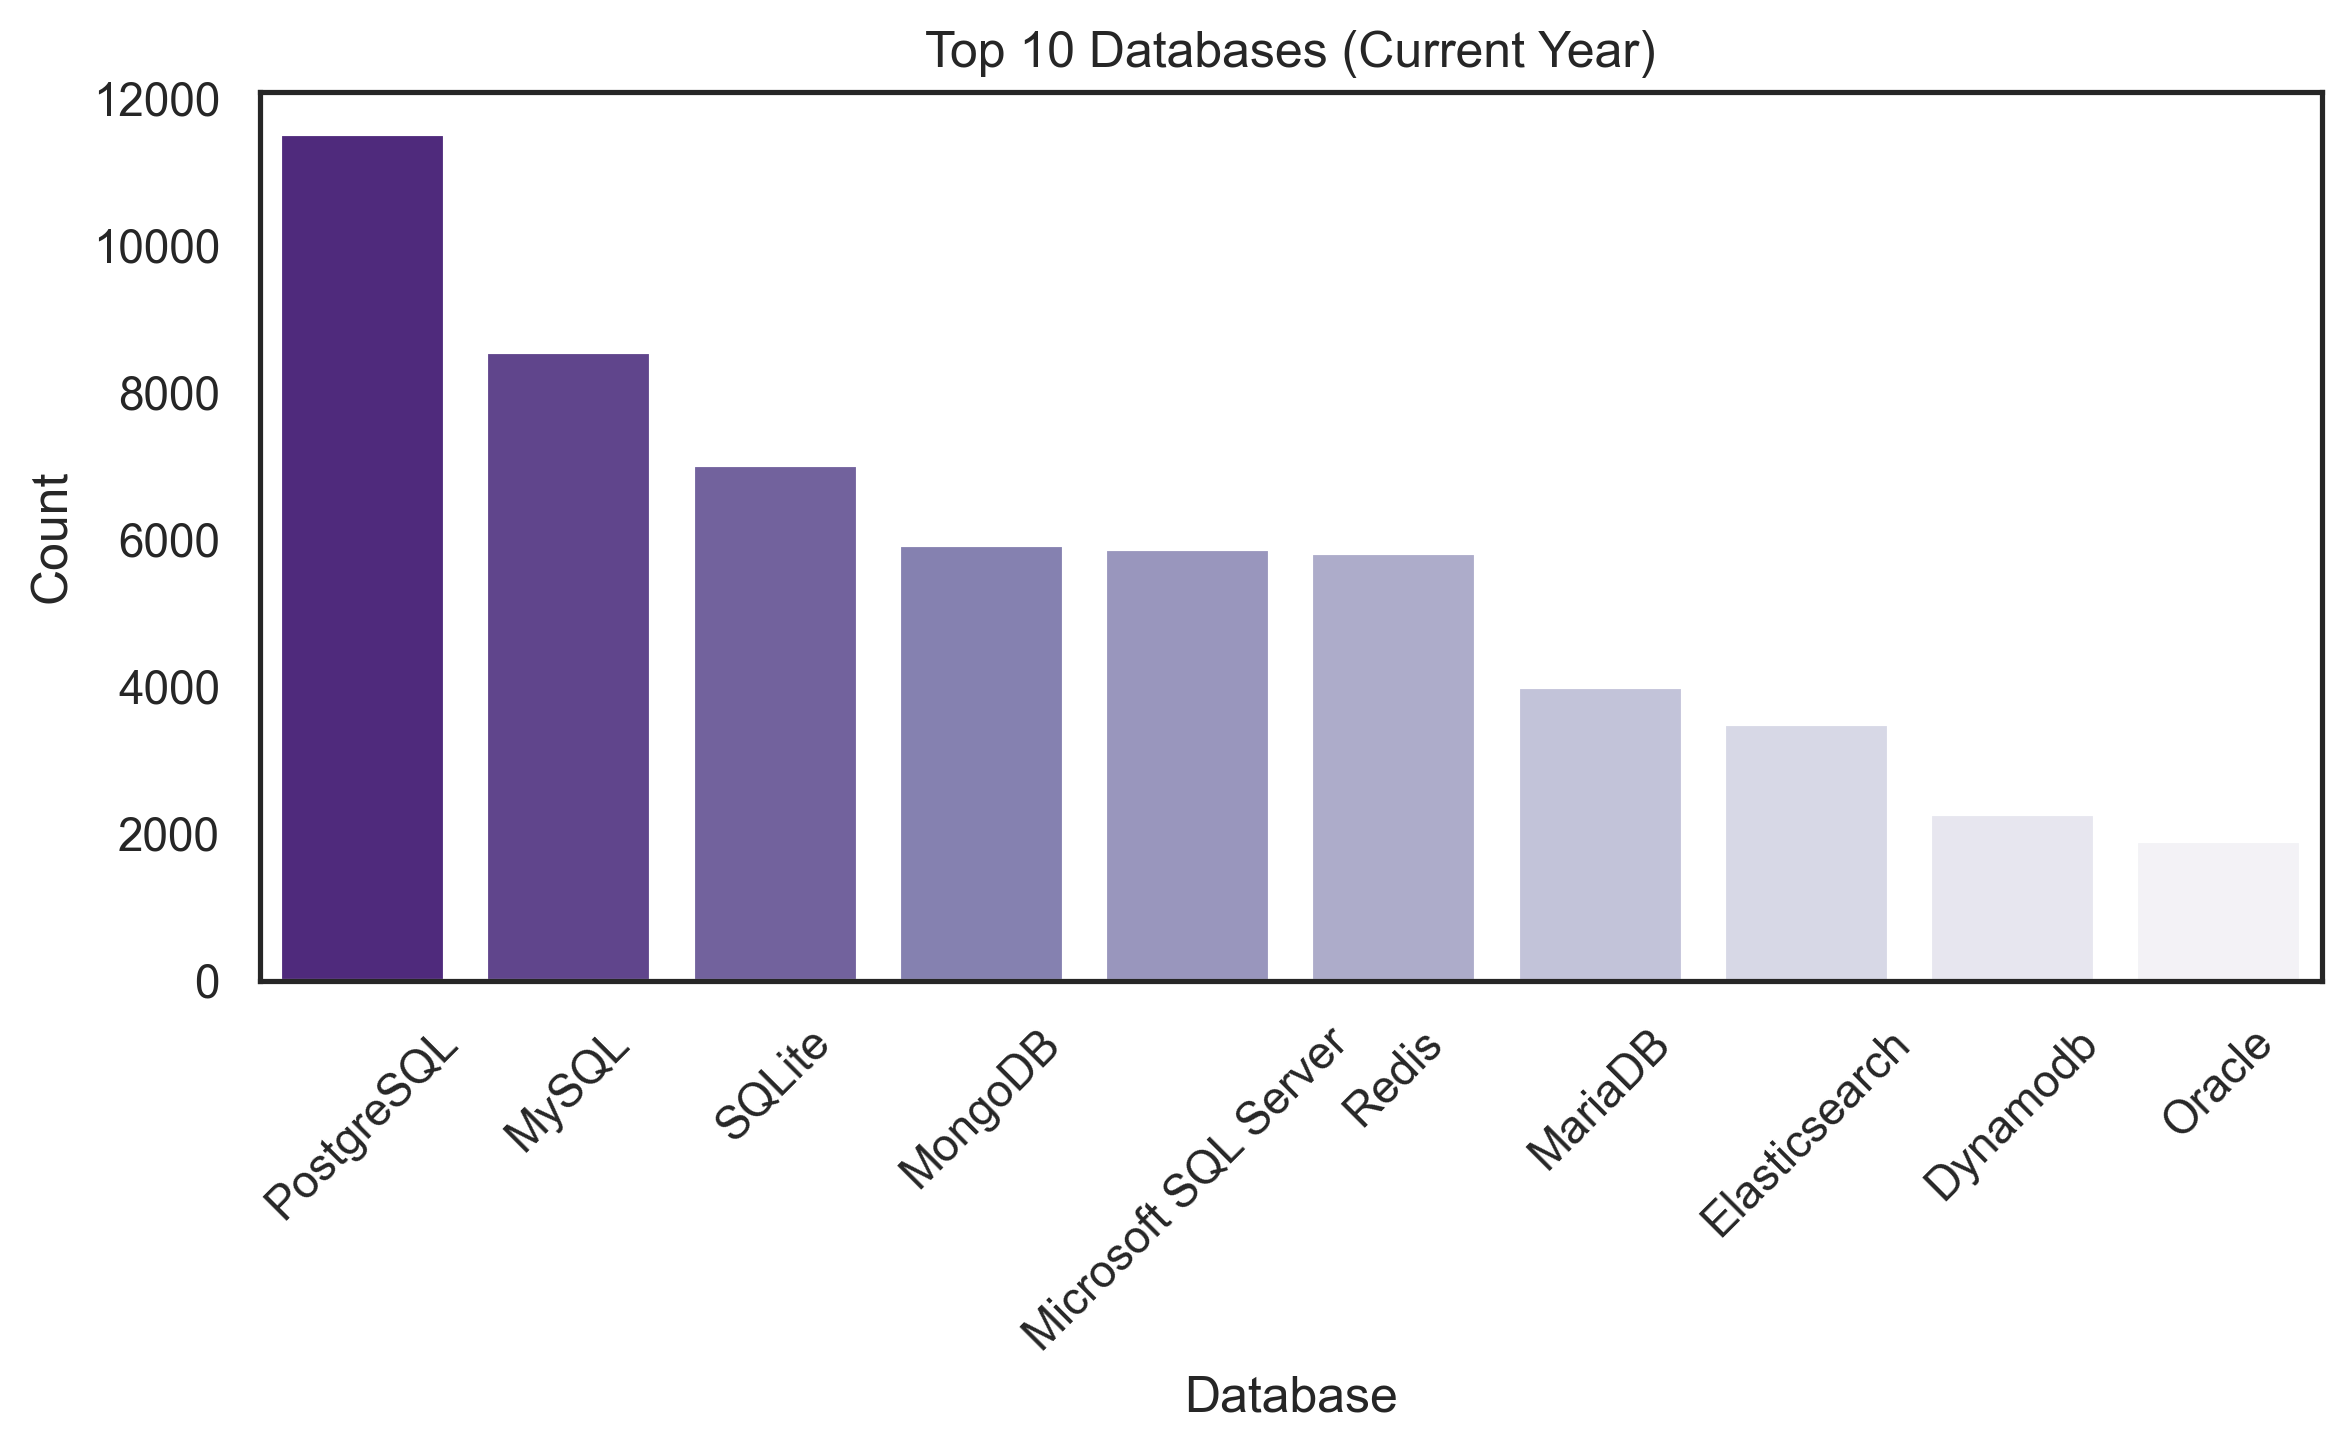

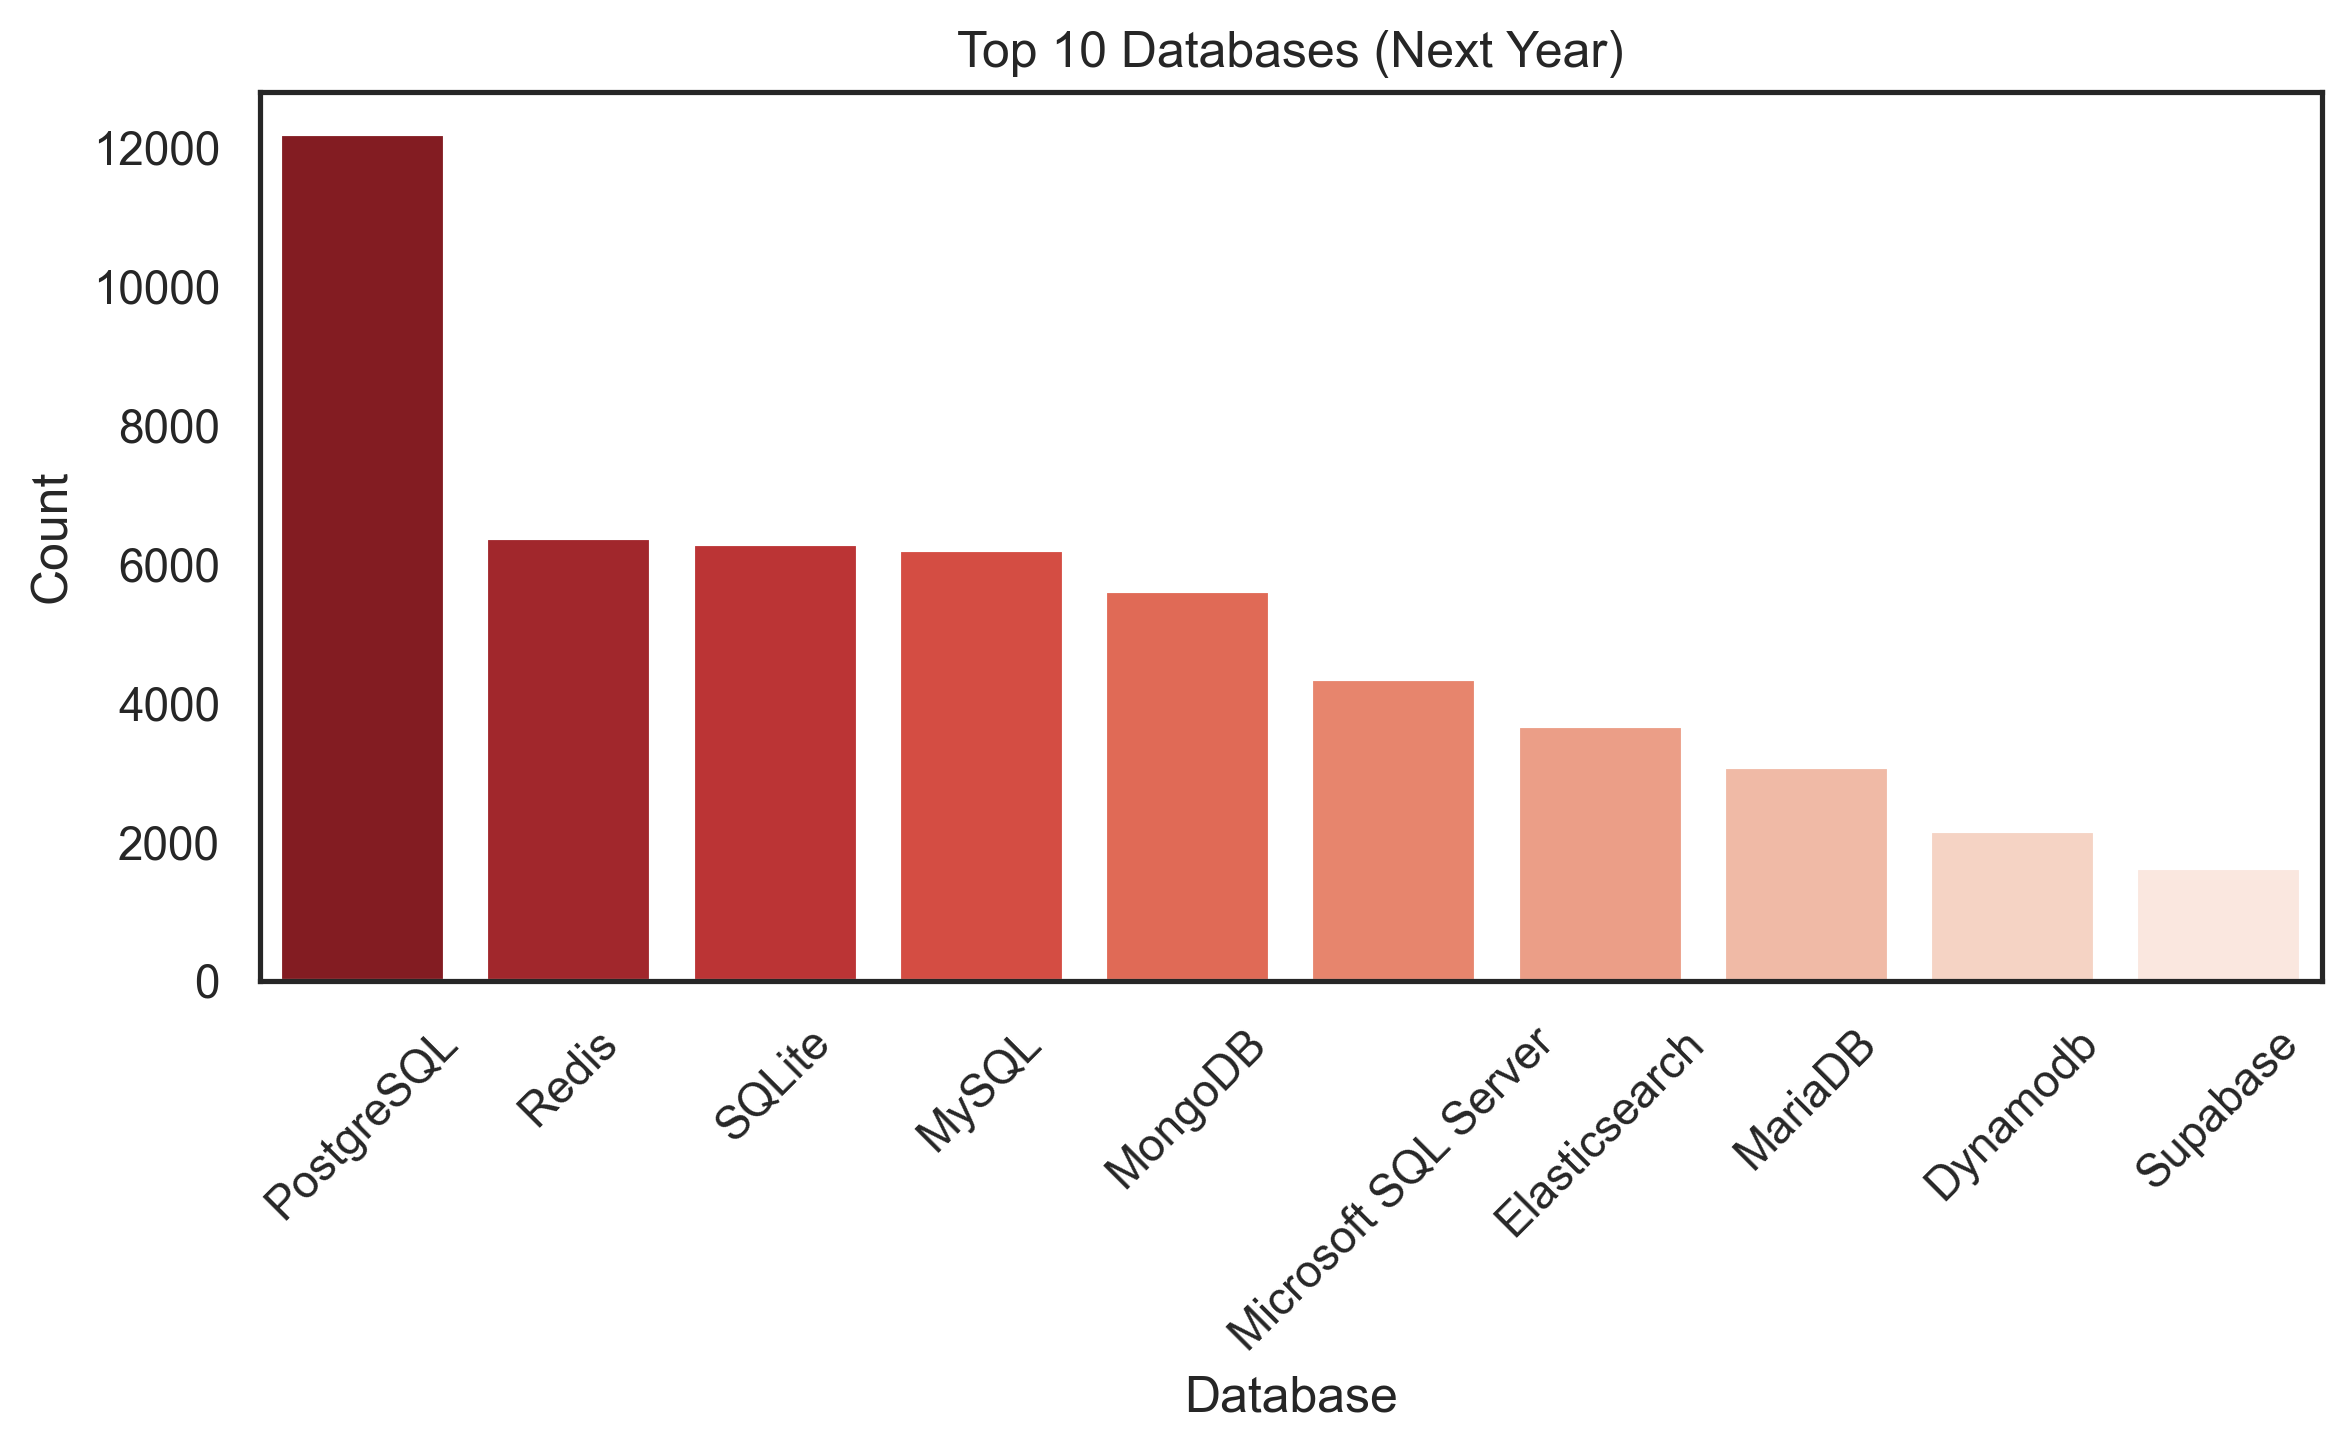

In [47]:
plot_bar_sns(
    top_lang_current,
    'Language',
    'Count',
    'Top 10 Programming Languages (Current Year)',
    'Blues_r',
    'lang_current.png'
)

plot_bar_sns(
    top_lang_future,
    'Language',
    'Count',
    'Top 10 Programming Languages (Next Year)',
    'Greens_r',
    'lang_future.png'
)

plot_bar_sns(
    top_db_current,
    'Database',
    'Count',
    'Top 10 Databases (Current Year)',
    'Purples_r',
    'db_current.png'
)

plot_bar_sns(
    top_db_future,
    'Database',
    'Count',
    'Top 10 Databases (Next Year)',
    'Reds_r',
    'db_future.png'
)